# Titanic Survival Analysis - Modeling

In this notebook, we train machine learning models to predict passenger survival based on the engineered features.

We evaluate model performance and identify which features contribute most to accurate predictions.

Goals:

- Split the dataset into training and testing sets  
- Train machine learning models  
- Evaluate model performance  
- Identify important features  

# Import libraries


In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [3]:
df = pd.read_csv("../data/processed/titanic_featured.csv")

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,0,22.0,1,0,7.2500,False,True,2,0,False,True,False,False
1,2,1,1,1,38.0,1,0,71.2833,False,False,2,0,False,False,True,False
2,3,1,3,1,26.0,0,0,7.9250,False,True,1,1,True,False,False,False
3,4,1,1,1,35.0,1,0,53.1000,False,True,2,0,False,False,True,False
4,5,0,3,0,35.0,0,0,8.0500,False,True,1,1,False,True,False,False


##  Feature and Target Separation

We separate the independent variables (features) from the target variable (Survived).

In [4]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

##  Train/Test Split

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Model Training

We use a Random Forest classifier, a robust ensemble model suitable for structured data.

In [6]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##  Predictions

We use the trained model to make predictions on the test set.

In [7]:
y_pred = model.predict(X_test)

## Model Evaluation

We evaluate the model using accuracy as the primary metric.

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8492


##  Feature Importance

We analyze which features contribute the most to the model's predictions.

In [9]:
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
0,PassengerId,0.179378
6,Fare,0.167597
3,Age,0.138497
12,Title_Mr,0.120139
2,Sex,0.119277
1,Pclass,0.072981
9,FamilySize,0.044725
13,Title_Mrs,0.033618
4,SibSp,0.030963
11,Title_Miss,0.025757


# Top features

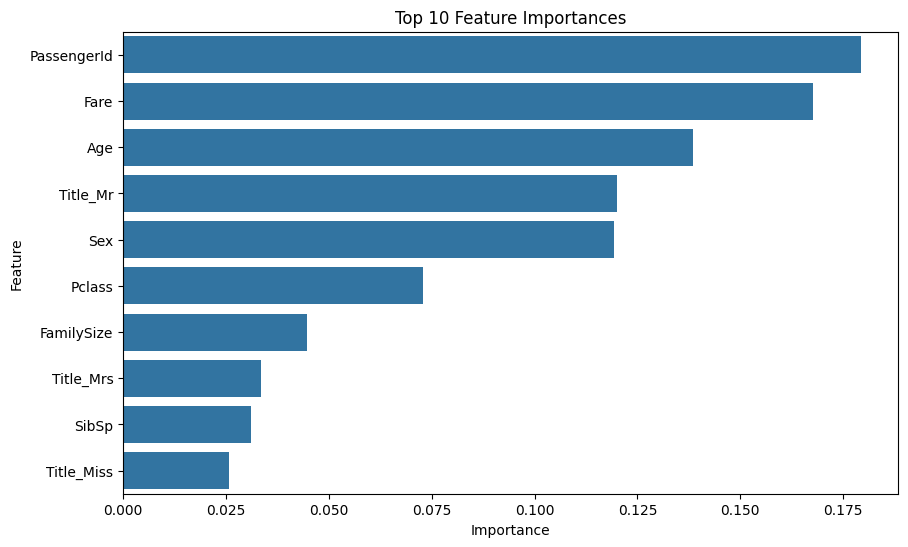

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Feature Importances")
plt.show()